In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [1]:
import pandas as pd
import time
# import os
# import sys
# from dotenv import load_dotenv, find_dotenv
# load_dotenv(sys.path[0]+'/.env')
import threading
from NLTK_utils import Twitter_Scraper, concat_and_save_to_csv
from NLTK_utils import preprocess_text_column
from NLTK_utils import apply_vader
from NLTK_utils import train_and_evaluate
from NLTK_utils import plot_sentiment_timeseries
from NLTK_utils import final_corr

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Vishwa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Vishwa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Vishwa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Vishwa\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
USER_UNAME = '@MBean1xy'
USER_PASSWORD = 'MRqpwo1029'

scraper = Twitter_Scraper(
    username=USER_UNAME,
    password=USER_PASSWORD,
)

scraper.login()

stop_event = threading.Event()
# Background function
def background_task():
    while not stop_event.is_set():
        scraper.scrape_tweets(
        scrape_query="Bitcoin",
        scrape_latest=True,
        )
        concat_and_save_to_csv(scraper.get_tweets(), poster_details=scraper.scraper_details["poster_details"])
        time.sleep(300)

# Background thread
thread = threading.Thread(target=background_task)
thread.start()

Initializing Twitter Scraper...
Setup WebDriver...
Initializing ChromeDriver...
Initializing ChromeDriver...
WebDriver Setup Complete

Logging in to Twitter...
Re-attempting to input username...

Login Successful



In [ ]:
# Stop threading execution
stop_event.set()
scraper.driver.close() 

NameError: name 'stop_event' is not defined

### Data Reading

In [3]:
# Load the extracted CSV file
df = pd.read_csv("tweets/all_tweets.csv")
df.head()

,Name,Handle,Timestamp,Verified,Content,Comments,Retweets,Likes,Analytics,Tags,Mentions,Emojis,Profile Image,Tweet Link,Tweet ID,Bitcoin_Price,UnitTime,cleaned_text,tokens
0,AMELIA TRADING AND MINING INVESTMENT COMPANY,@Amelia_bitcoin1,2025-05-16T22:55:47.000Z,0.0,What we have here is real...... I can assure e...,0.0,0.0,0.0,0.0,[],[],[],https://pbs.twimg.com/profile_images/182227313...,https://x.com/Amelia_bitcoin1/status/192351273...,tweet_id:1923512733074423975,103459.0,2025-05-16 18:56:54.221263,What we have here is real...... I can assure e...,"['real', 'assure', 'everyone', 'platform', '10..."
1,Johnny Wanker,@JohnnyWanker4,2025-05-16T22:55:45.000Z,0.0,Culpa nossa que recusamos a adotar o bitcoin e...,0.0,0.0,0.0,0.0,[],[],[],https://pbs.twimg.com/profile_images/187934517...,https://x.com/JohnnyWanker4/status/19235127259...,tweet_id:1923512725935657179,103459.0,2025-05-16 18:56:54.221263,Culpa nossa que recusamos a adotar o bitcoin e...,"['culpa', 'nossa', 'que', 'recusamos', 'adotar..."
2,Bojack_Escarlata,@BojackEscarlata,2025-05-16T22:55:44.000Z,0.0,Hace algunos años en una entrevista me pregunt...,0.0,0.0,0.0,0.0,[],[],[],https://pbs.twimg.com/profile_images/189874733...,https://x.com/BojackEscarlata/status/192351272...,tweet_id:1923512720684400762,103459.0,2025-05-16 18:56:54.221263,Hace algunos años en una entrevista me pregunt...,"['hace', 'algunos', 'años', 'en', 'una', 'entr..."
3,Moms-In-Bitcoin,@MomsInBitcoin1,2025-05-16T22:55:44.000Z,1.0,Freedom matters. The network matters. Spent ...,0.0,0.0,0.0,0.0,[],[],[],https://pbs.twimg.com/profile_images/186801548...,https://x.com/MomsInBitcoin1/status/1923512719...,tweet_id:1923512719510016439,103459.0,2025-05-16 18:56:54.221263,Freedom matters. The network matters. Spent ...,"['freedom', 'matter', 'network', 'matter', 'sp..."
4,BITCAT - Bitcoin's Mascot,@BitCat_sol_,2025-05-16T22:55:42.000Z,1.0,Laughter is the best medicine! Just like how $...,0.0,0.0,0.0,0.0,[],[],[],https://pbs.twimg.com/profile_images/186885968...,https://x.com/BitCat_sol_/status/1923512712992...,tweet_id:1923512712992071876,103459.0,2025-05-16 18:56:54.221263,Laughter is the best medicine! Just like how $...,"['laughter', 'best', 'medicine', 'like', 'bitc..."


In [4]:
df.shape

(3803, 19)

In [5]:
# Apply VADER sentiment analysis and save result to 'sentiment_labeled.csv'
df = apply_vader(df)

In [6]:
# Train and evaluate classifier using sentiment labels
train_and_evaluate(df)

Model Evaluation
Accuracy: 0.7306176084099869
Classification Report:
              precision    recall  f1-score   support

    negative       0.92      0.34      0.50       169
     neutral       0.73      0.84      0.78       305
    positive       0.69      0.84      0.76       287

    accuracy                           0.73       761
   macro avg       0.78      0.68      0.68       761
weighted avg       0.76      0.73      0.71       761



In [7]:
df.head()

,Name,Handle,Timestamp,Verified,Content,Comments,Retweets,Likes,Analytics,Tags,...,Tweet ID,Bitcoin_Price,UnitTime,cleaned_text,tokens,compound,positive,neutral,negative,sentiment_label
0,AMELIA TRADING AND MINING INVESTMENT COMPANY,@Amelia_bitcoin1,2025-05-16T22:55:47.000Z,0.0,What we have here is real...... I can assure e...,0.0,0.0,0.0,0.0,[],...,tweet_id:1923512733074423975,103459.0,2025-05-16 18:56:54.221263,What we have here is real...... I can assure e...,"['real', 'assure', 'everyone', 'platform', '10...",0.8555,0.241,0.672,0.087,positive
1,Johnny Wanker,@JohnnyWanker4,2025-05-16T22:55:45.000Z,0.0,Culpa nossa que recusamos a adotar o bitcoin e...,0.0,0.0,0.0,0.0,[],...,tweet_id:1923512725935657179,103459.0,2025-05-16 18:56:54.221263,Culpa nossa que recusamos a adotar o bitcoin e...,"['culpa', 'nossa', 'que', 'recusamos', 'adotar...",0.0000,0.000,1.000,0.000,neutral
2,Bojack_Escarlata,@BojackEscarlata,2025-05-16T22:55:44.000Z,0.0,Hace algunos años en una entrevista me pregunt...,0.0,0.0,0.0,0.0,[],...,tweet_id:1923512720684400762,103459.0,2025-05-16 18:56:54.221263,Hace algunos años en una entrevista me pregunt...,"['hace', 'algunos', 'años', 'en', 'una', 'entr...",-0.7906,0.000,0.849,0.151,negative
3,Moms-In-Bitcoin,@MomsInBitcoin1,2025-05-16T22:55:44.000Z,1.0,Freedom matters. The network matters. Spent ...,0.0,0.0,0.0,0.0,[],...,tweet_id:1923512719510016439,103459.0,2025-05-16 18:56:54.221263,Freedom matters. The network matters. Spent ...,"['freedom', 'matter', 'network', 'matter', 'sp...",0.6597,0.561,0.439,0.000,positive
4,BITCAT - Bitcoin's Mascot,@BitCat_sol_,2025-05-16T22:55:42.000Z,1.0,Laughter is the best medicine! Just like how $...,0.0,0.0,0.0,0.0,[],...,tweet_id:1923512712992071876,103459.0,2025-05-16 18:56:54.221263,Laughter is the best medicine! Just like how $...,"['laughter', 'best', 'medicine', 'like', 'bitc...",0.9627,0.586,0.414,0.000,positive


In [8]:
df.tail()

,Name,Handle,Timestamp,Verified,Content,Comments,Retweets,Likes,Analytics,Tags,...,Tweet ID,Bitcoin_Price,UnitTime,cleaned_text,tokens,compound,positive,neutral,negative,sentiment_label
3798,Xbot,@x64507TREND,2025-05-17T02:30:23.000Z,0.0,"1 BTC = ￥15,071,226\n1 ETH = ￥362,691\n INVEST...",0.0,0.0,0.0,29,"['#Bitcoin', '#Crypto', '#Bull', '#HODL']",...,tweet_id:1923566741411725819,103111.0,2025-05-16 22:34:47.997931,"1 BTC = ￥15,071,226\n1 ETH = ￥362,691\n INVEST...","['1', 'btc', '15071226', '1', 'eth', '362691',...",0.0000,0.000,1.000,0.0,neutral
3799,Hack with karl,@Karl_help_desk,2025-05-17T02:30:20.000Z,0.0,#snaphack #buyingcontent #monkeyappgirls #cry...,0.0,0.0,0.0,49,"['#snaphack', '#buyingcontent', '#monkeyappgir...",...,tweet_id:1923566726504997237,103111.0,2025-05-16 22:34:47.997931,#snaphack #buyingcontent #monkeyappgirls #cry...,"['first', 'thought', 'wow', 'malware', 'scrapi...",0.5859,0.128,0.872,0.0,positive
3800,TU ZONA CRYPTO,@Tuzona_Crypto,2025-05-17T02:30:19.000Z,0.0,#Cryptocurency BEAMXUSDT\n Long\nEntry Targets...,0.0,0.0,0.0,8,"['#Cryptocurency', '#Crypto', '#bitcoin', '#BT...",...,tweet_id:1923566723808080118,103111.0,2025-05-16 22:34:47.997931,#Cryptocurency BEAMXUSDT\n Long\nEntry Targets...,"['beamxusdt', 'long', 'entry', 'target', '0007...",0.4404,0.086,0.914,0.0,positive
3801,George Huseman,@GeorgeHuseman,2025-05-17T02:30:19.000Z,0.0,"Nothing stops this train, buy bitcoin.",0.0,0.0,0.0,7,[],...,tweet_id:1923566721908318468,103111.0,2025-05-16 22:34:47.997931,"Nothing stops this train, buy bitcoin.","['nothing', 'stop', 'train', 'buy', 'bitcoin']",0.1139,0.224,0.776,0.0,positive
3802,Croaks Butter nexyai.io,@Bitcoin_broski,2025-05-17T02:30:18.000Z,0.0,LFG,0.0,0.0,0.0,3,[],...,tweet_id:1923566720050135263,103111.0,2025-05-16 22:34:47.997931,LFG,['lfg'],0.0000,0.000,1.000,0.0,neutral


In [9]:
df = df.groupby(['UnitTime']).agg({'Bitcoin_Price':'max','compound':'mean'}).reset_index()
df['Time'] = pd.to_datetime(df['UnitTime'], errors='coerce')
df = df.sort_values(by=['Time'])
df.head()

,UnitTime,Bitcoin_Price,compound,Time
0,2025-05-16 18:56:54.221263,103459.0,0.092157,2025-05-16 18:56:54.221263
1,2025-05-16 18:59:18.053066,103457.0,0.138745,2025-05-16 18:59:18.053066
2,2025-05-16 18:59:18.323556,103457.0,0.137627,2025-05-16 18:59:18.323556
3,2025-05-16 19:01:29.285587,103464.0,0.078239,2025-05-16 19:01:29.285587
4,2025-05-16 19:03:30.594161,103480.0,0.139608,2025-05-16 19:03:30.594161


In [10]:
df.tail()

,UnitTime,Bitcoin_Price,compound,Time
34,2025-05-16 22:03:11.771747,102834.0,0.103885,2025-05-16 22:03:11.771747
35,2025-05-16 22:09:49.252130,102933.0,0.163533,2025-05-16 22:09:49.252130
36,2025-05-16 22:16:11.299782,102893.0,0.124031,2025-05-16 22:16:11.299782
37,2025-05-16 22:22:47.917339,102937.0,0.157603,2025-05-16 22:22:47.917339
38,2025-05-16 22:34:47.997931,103111.0,0.178768,2025-05-16 22:34:47.997931


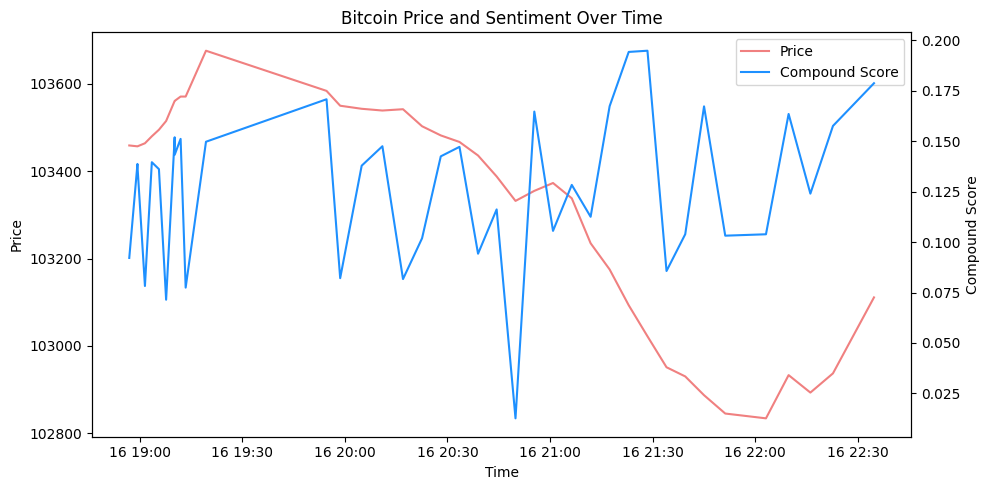

In [11]:
plot_sentiment_timeseries(df)

(39, 7)
                     UnitTime  Bitcoin_Price  compound  \
0  2025-05-16 18:56:54.221263       103459.0  0.092157   
1  2025-05-16 18:59:18.053066       103457.0  0.138745   
2  2025-05-16 18:59:18.323556       103457.0  0.137627   
3  2025-05-16 19:01:29.285587       103464.0  0.078239   
4  2025-05-16 19:03:30.594161       103480.0  0.139608   

                        Time Sentiment  Bitcoin_Price_Diff Movement  
0 2025-05-16 18:56:54.221263  positive                 NaN   stable  
1 2025-05-16 18:59:18.053066  positive           -0.000019     down  
2 2025-05-16 18:59:18.323556  positive            0.000000   stable  
3 2025-05-16 19:01:29.285587  positive            0.000068       up  
4 2025-05-16 19:03:30.594161  positive            0.000155       up  


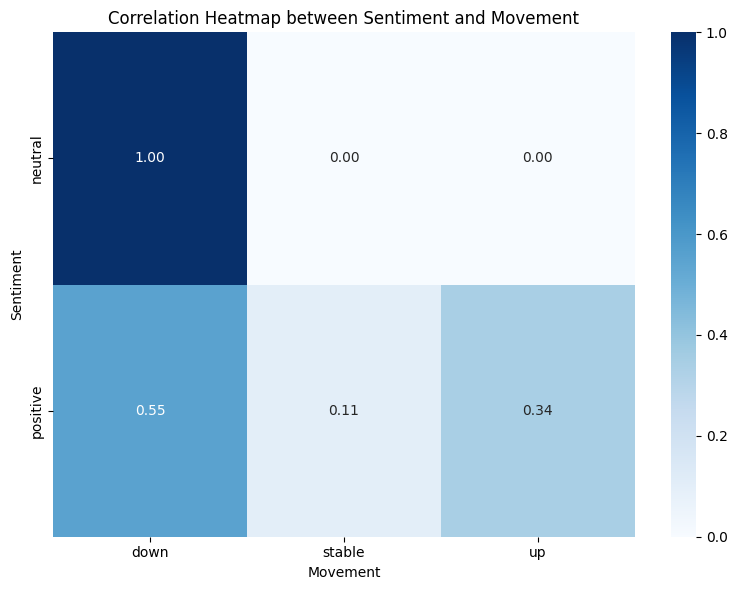

Scraping Latest Tweets from Bitcoin search...
Progress: [[========================================]] 100.00% 100 of 100
Scraping Complete
Tweets: 100 out of 100

Saved 100 new tweets. All tweets 3903
Scraping Latest Tweets from Bitcoin search...
Progress: [[==============================----------]] 77.00% 77 of 100
No more tweets to scrape

Scraping Incomplete
Tweets: 77 out of 100

Saved 77 new tweets. All tweets 3980
Scraping Latest Tweets from Bitcoin search...
Progress: [[========================================]] 100.00% 100 of 100
Scraping Complete
Tweets: 100 out of 100

Saved 100 new tweets. All tweets 4080


In [ ]:
final_corr(df)